# Bert Model

In [22]:
import sys
import os
import matplotlib.pyplot as plt
from pathlib import Path
from src.model.predict_model import predict_sentiment_bert
import json

reviews = [
        "this movie was great and the acting was amazing",
        "this movie was mid"]

for review in reviews:
    print("BERT Prediction:", predict_sentiment_bert(review))
    print("BERT Prediction with best params:", predict_sentiment_bert(review, with_params=True))

BERT Prediction: positive (confidence: 99.93%)
BERT Prediction with best params: positive (confidence: 99.87%)
BERT Prediction: negative (confidence: 99.47%)
BERT Prediction with best params: negative (confidence: 59.60%)


In [23]:
models = {
    "BERT Base": Path("models/bert_model"),
    "BERT Optimized": Path("models/bert_model_with_params")
}

def load_model_data(models):
    """Helper function to load data from both models"""
    colors = ['blue', 'red']
    all_model_data = {}
    
    for model_idx, (model_name, model_dir) in enumerate(models.items()):
        if not model_dir.exists():
            print(f"Model directory {model_dir} doesn't exist")
            continue
            
        checkpoints = list(model_dir.glob("checkpoint-*"))
        if not checkpoints:
            print(f"No checkpoints found in {model_dir}")
            continue
            
        last_checkpoint = sorted(checkpoints, key=lambda x: int(x.name.split('-')[1]))[-1]
        
        epochs = []
        train_losses = []
        learning_rates = []
        grad_norms = []
        
        
        trainer_state_path = last_checkpoint / "trainer_state.json"
        if trainer_state_path.exists():
            with open(trainer_state_path, 'r') as f:
                state = json.load(f)
            
            for log_entry in state.get('log_history', []):
                if 'epoch' in log_entry:
                    epochs.append(log_entry['epoch'])
                if 'loss' in log_entry:
                    train_losses.append(log_entry['loss'])
                if 'learning_rate' in log_entry:
                    learning_rates.append(log_entry['learning_rate'])
                if 'grad_norm' in log_entry:
                    grad_norms.append(log_entry['grad_norm'])
        
        if not epochs:
            print(f"No training data found for {model_name}")
            continue
        
        all_model_data[model_name] = {
            'epochs': epochs,
            'train_losses': train_losses,
            'learning_rates': learning_rates,
            'grad_norms': grad_norms,
            'color': colors[model_idx]
        }
            
    return all_model_data
    
def plot_training_loss():    
    all_model_data = load_model_data(models)
    
    plt.figure(figsize=(10, 6))
    
    for model_name, data in all_model_data.items():
        if data['train_losses']:
            plt.plot(data['epochs'], data['train_losses'], 
                    color=data['color'], linewidth=2, label=model_name)
    
    plt.title('Training Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_learning_rate():    
    all_model_data = load_model_data(models)
    
    plt.figure(figsize=(10, 6))
    
    for model_name, data in all_model_data.items():
        if data['learning_rates']:
            plt.plot(data['epochs'], data['learning_rates'], 
                    color=data['color'], linewidth=2, label=model_name)
    
    plt.title('Learning Rate Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)
    plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    plt.tight_layout()
    plt.show()

def plot_gradient_norms():
    all_model_data = load_model_data(models)
    
    plt.figure(figsize=(10, 6))
    
    for model_name, data in all_model_data.items():
        if data['grad_norms']:
            plt.plot(data['epochs'], data['grad_norms'], 
                    color=data['color'], linewidth=2, label=model_name)
    
    plt.title('Gradient Norms Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Gradient Norm')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_smoothed_loss():
    all_model_data = load_model_data(models)
    
    plt.figure(figsize=(10, 6))
    
    for model_name, data in all_model_data.items():
        train_losses = data['train_losses']
        epochs = data['epochs']
        color = data['color']
        
        if len(train_losses) > 10:
            window_size = min(10, len(train_losses) // 5)
            smoothed_loss = []
            smoothed_epochs = []
            
            for i in range(window_size, len(train_losses)):
                smoothed_loss.append(sum(train_losses[i-window_size:i]) / window_size)
                smoothed_epochs.append(epochs[i])
            
            plt.plot(epochs, train_losses, alpha=0.3, color=color, linestyle='--', label=f'{model_name} (Raw)')
            plt.plot(smoothed_epochs, smoothed_loss, color=color, linewidth=2, label=f'{model_name} (Smoothed)')
    
    plt.title('Loss Trend Comparison (Smoothed)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_final_loss_comparison():
    
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'red']
    
    final_losses = []
    model_names = []
    
    for model_idx, (model_name, model_dir) in enumerate(models.items()):
        if model_dir.exists():
            checkpoints = list(model_dir.glob("checkpoint-*"))
            if checkpoints:
                last_checkpoint = sorted(checkpoints, key=lambda x: int(x.name.split('-')[1]))[-1]
                trainer_state_path = last_checkpoint / "trainer_state.json"
                
                if trainer_state_path.exists():
                    with open(trainer_state_path, 'r') as f:
                        state = json.load(f)
                    
                    log_history = state.get('log_history', [])
                    if log_history:
                        final_loss = log_history[-1].get('loss', 0)
                        final_losses.append(final_loss)
                        model_names.append(model_name)
    
    if final_losses:
        bars = plt.bar(model_names, final_losses, color=colors[:len(final_losses)], alpha=0.7)
        
        for bar, loss in zip(bars, final_losses):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{loss:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.title('Final Training Loss Comparison')
    plt.ylabel('Loss')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


### 1. Training Loss Comparison

This chart shows how well each model learned to predict sentiment during training. Training loss measures prediction errors - lower values mean better performance. Both models start around 0.6 (random guessing) and should decrease as they learn. The blue line represents the base BERT model, while the red line shows the optimized version with tuned hyperparameters. A steady downward trend reaching below 0.3 indicates successful learning.

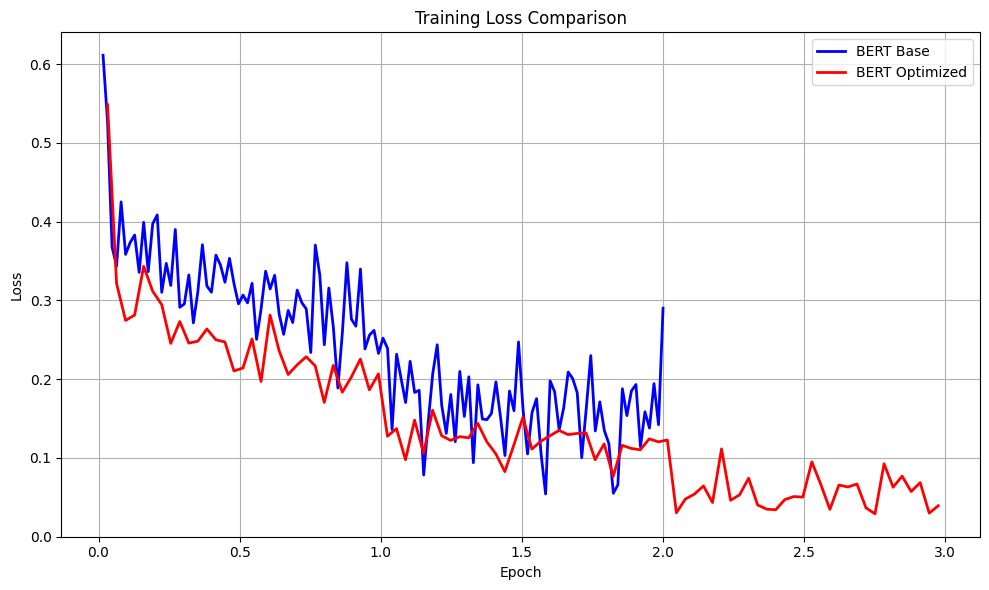

In [24]:
plot_training_loss()

### 2. Learning Rate Schedule

This displays how the learning rate changed during training for each model. Learning rate controls how aggressively the model updates its parameters. Most fine-tuning uses values between 1e-5 and 5e-5, starting higher for rapid learning and decreasing over time for stability. Different learning rate schedules can significantly impact final model performance.

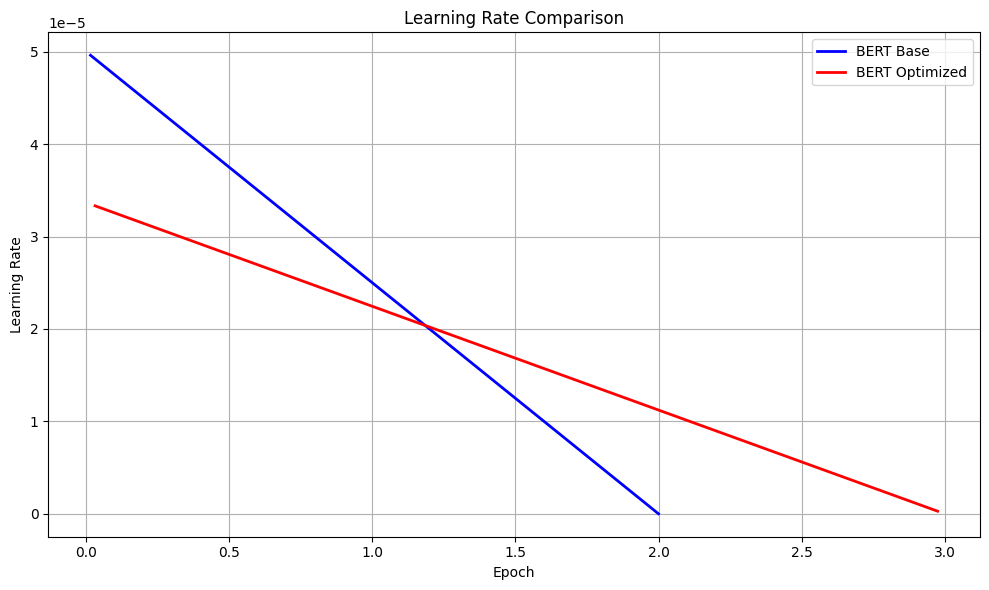

In [25]:
plot_learning_rate()

### 3. Gradient Norms

This chart monitors training stability by showing gradient magnitudes during optimization. Values between 1-10 indicate healthy training, while very high values (>20) suggest instability and very low values (<0.1) indicate the model has stopped learning effectively. Stable, gradually decreasing norms throughout training are ideal.

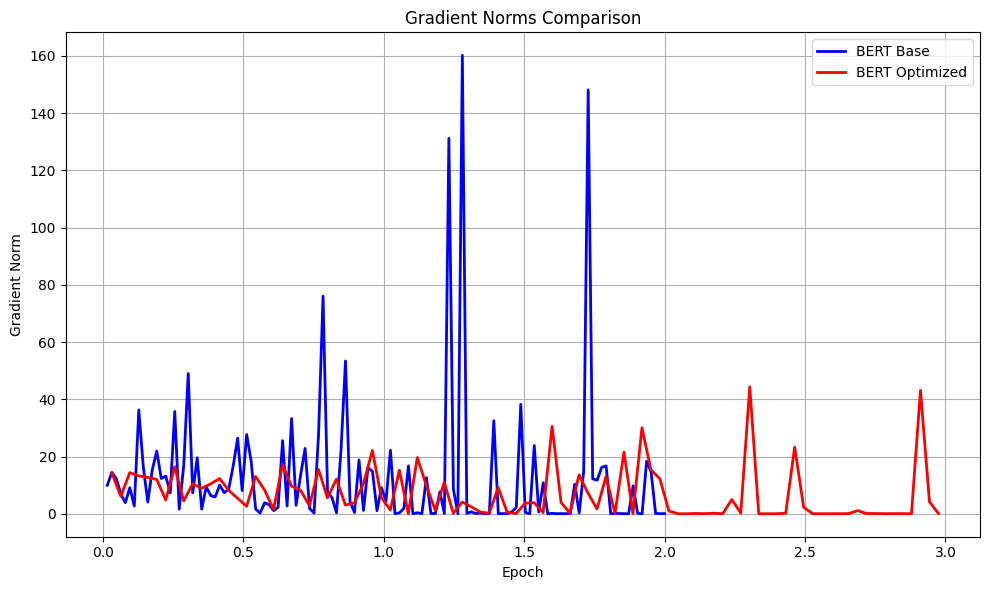

In [26]:
plot_gradient_norms()

### 4. Smoothed Loss Trend

This provides a cleaner view of learning progress by filtering out training noise. The dashed lines show raw loss values with natural fluctuations, while solid lines display smoothed trends using moving averages. This makes it easier to compare which model learned more consistently and reached better final performance.

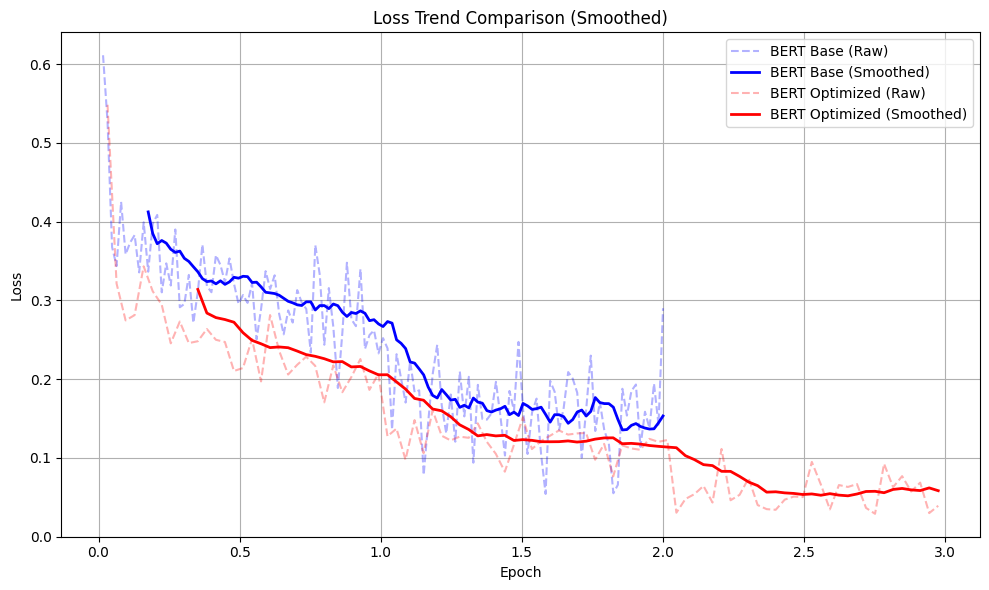

In [18]:
plot_smoothed_loss()

### 5. Final Training Loss

This bar chart compares the final loss values achieved by each model after complete training. It directly answers which model performed better overall. Lower bars indicate superior performance. Values below 0.1 are excellent, 0.1-0.2 are very good, and above 0.3 may need improvement.

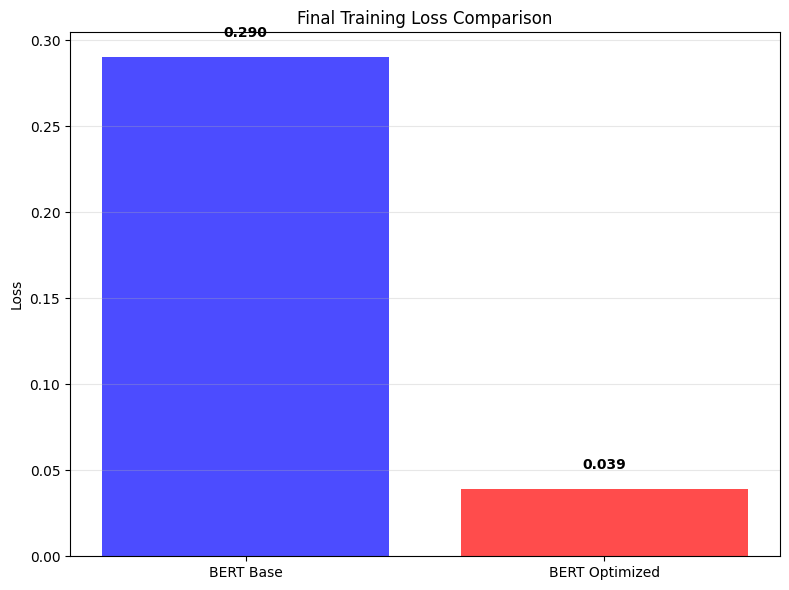

In [19]:
plot_final_loss_comparison()